## 1. Environment Setup

In [ ]:
%pip install -q xgboost lightgbm imbalanced-learn shap

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Metrics
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score,
    matthews_corrcoef, confusion_matrix, roc_curve, roc_auc_score,
    ConfusionMatrixDisplay, classification_report
)

# Explainability
import shap

import time
import gc
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110

## 2. Load and Merge the Dataset

In [ ]:
RANDOM_STATE = 42

def reduce_mem_usage(df):
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="float")
    return df

def read_ieee_csv(path, chunksize=100_000):
    chunks = []
    for chunk in pd.read_csv(
        path,
        encoding="utf-8-sig",
        chunksize=chunksize,
        low_memory=False
    ):
        chunks.append(reduce_mem_usage(chunk))
    df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()
    return df

print("Memory-efficient loading helpers ready")

Memory-efficient loading helpers ready


In [ ]:
import os

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/fraud_detection/ieee_cis/"

print("Files found in", DATA_DIR)
for fname in sorted(os.listdir(DATA_DIR)):
    print(" -", fname)

train_tx_path = os.path.join(DATA_DIR, "train_transaction.csv")
train_id_path = os.path.join(DATA_DIR, "train_identity.csv")
test_tx_path = os.path.join(DATA_DIR, "test_transaction.csv")
test_id_path = os.path.join(DATA_DIR, "test_identity.csv")

print("Loading train_transaction...")
train_tx = read_ieee_csv(train_tx_path)

print("Loading train_identity...")
train_id = read_ieee_csv(train_id_path)

print("Loading test_transaction...")
test_tx = read_ieee_csv(test_tx_path)

print("Loading test_identity...")
test_id = read_ieee_csv(test_id_path)

test_id.columns = [c.replace("-", "_") for c in test_id.columns]

print(f"\nLoaded train_transaction: {train_tx.shape}")
print(f"Loaded train_identity:    {train_id.shape}")
print(f"Loaded test_transaction:  {test_tx.shape}")
print(f"Loaded test_identity:     {test_id.shape}")

Mounted at /content/drive
Files found in /content/drive/MyDrive/fraud_detection/ieee_cis/
 - IEEE_CIS_Fraud_Detection_Pipeline.ipynb
 - IEEE_CIS_Fraud_Detection_Pipeline_2.ipynb
 - IEEE_CIS_Fraud_Detection_Pipeline_4.ipynb
 - IEEE_CIS_Fraud_Detection_Pipeline_6.ipynb
 - sample_submission.csv
 - test_identity.csv
 - test_transaction.csv
 - train_identity.csv
 - train_transaction.csv
Loading train_transaction...
Loading train_identity...
Loading test_transaction...
Loading test_identity...

Loaded train_transaction: (590540, 394)
Loaded train_identity:    (144233, 41)
Loaded test_transaction:  (506691, 393)
Loaded test_identity:     (141907, 41)


In [ ]:
train = train_tx.merge(train_id, on="TransactionID", how="left")
test  = test_tx.merge(test_id, on="TransactionID", how="left")

# free memory now that we have the merged versions
del train_tx, train_id, test_tx, test_id
gc.collect()

# make sure isFraud is int, not text
train["isFraud"] = train["isFraud"].astype(int)

print(f"Merged training set: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Merged test set:     {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"\nFraction of training transactions with a matched identity record: "
      f"{train['id_01'].notna().mean()*100:.1f}%")
train.head()

Merged training set: 590,540 rows x 434 columns
Merged test set:     506,691 rows x 433 columns

Fraction of training transactions with a matched identity record: 24.4%


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## 3. Exploratory Data Analysis

### 3.1 Class distribution

Class counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.499%  (imbalance ratio approx 28:1)


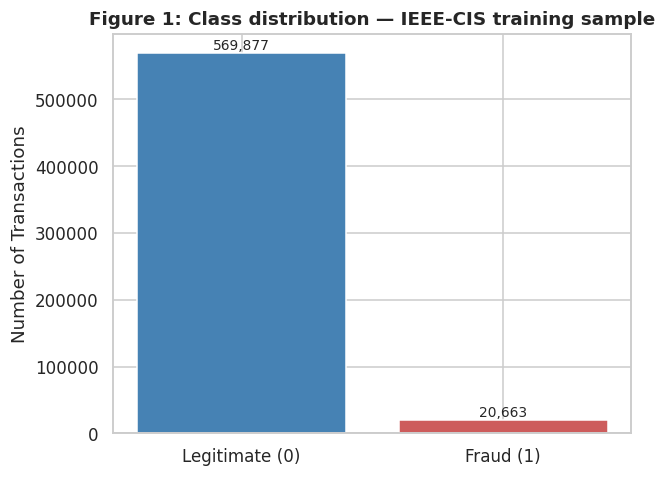

In [ ]:
fraud_counts = train["isFraud"].value_counts().sort_index()
fraud_pct = train["isFraud"].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(fraud_counts)
print(f"\nFraud rate: {fraud_pct[1]:.3f}%  (imbalance ratio approx {fraud_counts[0]/fraud_counts[1]:.0f}:1)")

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(["Legitimate (0)", "Fraud (1)"], fraud_counts.values, color=["steelblue", "indianred"])
ax.set_title("Figure 1: Class distribution — IEEE-CIS training sample", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Transactions")
for bar, count in zip(bars, fraud_counts.values):
    ax.annotate(f"{count:,}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", bbox_inches="tight")
plt.show()

### 3.2 Missing data overview

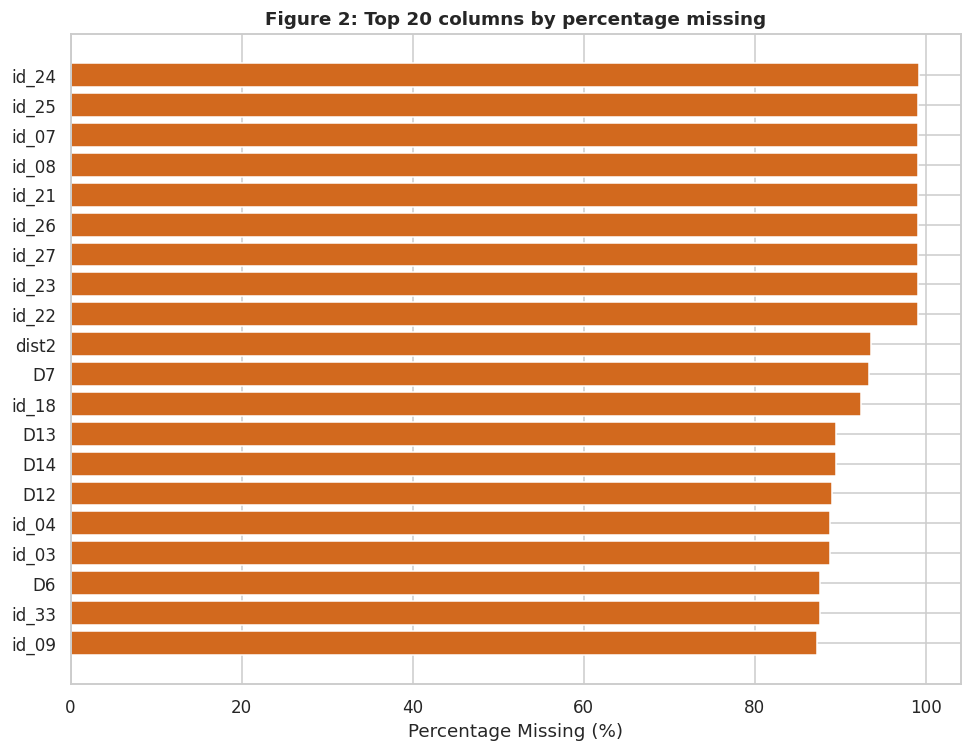

Columns with >50% missing: 214 out of 434
Columns with 0% missing:   20 out of 434


In [ ]:
missing_pct = (train.isna().mean() * 100).sort_values(ascending=False)
top_missing = missing_pct.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_missing.index[::-1], top_missing.values[::-1], color="chocolate")
ax.set_xlabel("Percentage Missing (%)")
ax.set_title("Figure 2: Top 20 columns by percentage missing", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_missing_data.png", bbox_inches="tight")
plt.show()

print(f"Columns with >50% missing: {(missing_pct > 50).sum()} out of {train.shape[1]}")
print(f"Columns with 0% missing:   {(missing_pct == 0).sum()} out of {train.shape[1]}")

### 3.3 Transaction amount by class

TransactionAmt summary — Legitimate:
count    569877.00
mean        134.51
std         239.40
min           0.25
25%          43.97
50%          68.50
75%         120.00
max       31937.39
Name: TransactionAmt, dtype: float64

TransactionAmt summary — Fraud:
count    20663.00
mean       149.24
std        232.21
min          0.29
25%         35.04
50%         75.00
75%        161.00
max       5191.00
Name: TransactionAmt, dtype: float64


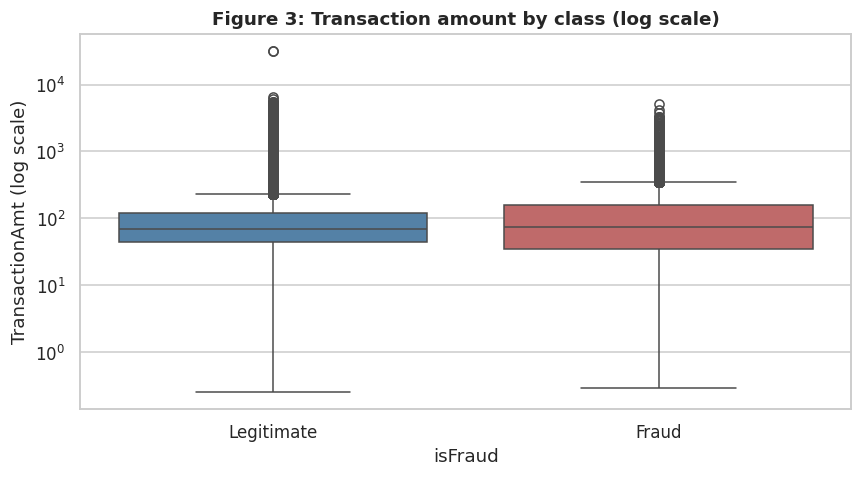

In [ ]:
print("TransactionAmt summary — Legitimate:")
print(train.loc[train["isFraud"] == 0, "TransactionAmt"].describe().round(2))
print("\nTransactionAmt summary — Fraud:")
print(train.loc[train["isFraud"] == 1, "TransactionAmt"].describe().round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(x="isFraud", y="TransactionAmt", data=train, ax=ax,
            palette=["steelblue", "indianred"])
ax.set_yscale("log")
ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_title("Figure 3: Transaction amount by class (log scale)", fontsize=12, fontweight="bold")
ax.set_ylabel("TransactionAmt (log scale)")
plt.tight_layout()
plt.savefig("fig3_amount_by_class.png", bbox_inches="tight")
plt.show()

### 3.4 Key categorical features

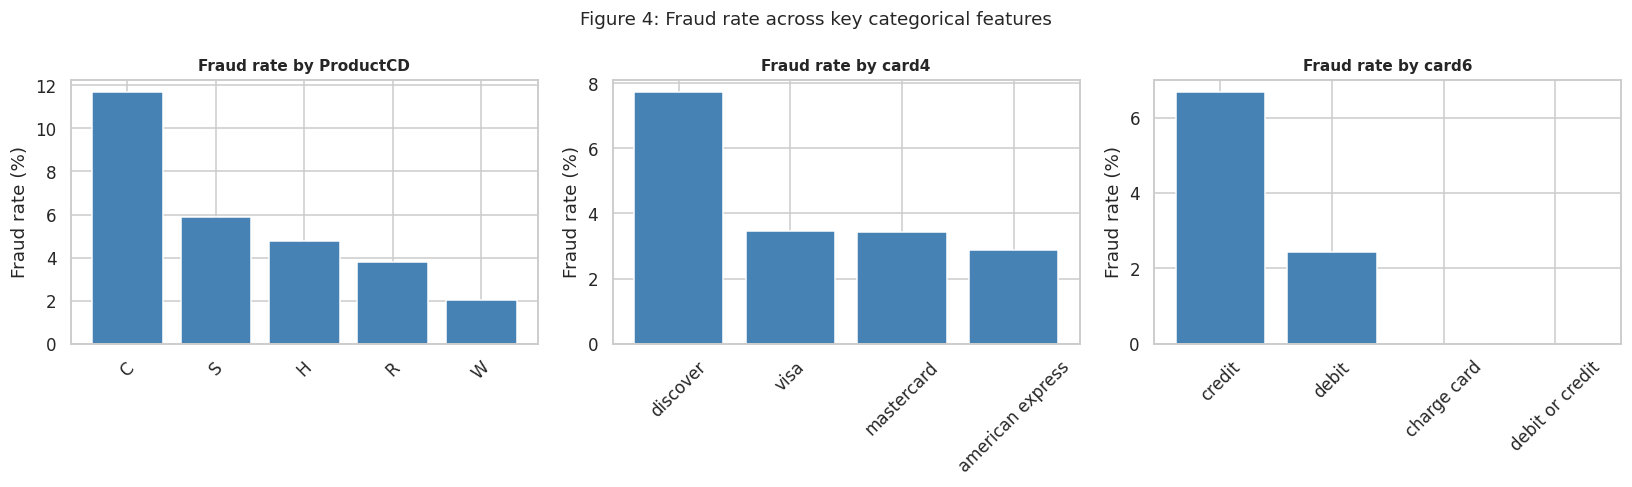

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col in zip(axes, ["ProductCD", "card4", "card6"]):
    fraud_rate_by_cat = train.groupby(col)["isFraud"].mean().sort_values(ascending=False) * 100
    ax.bar(fraud_rate_by_cat.index.astype(str), fraud_rate_by_cat.values, color="steelblue")
    ax.set_title(f"Fraud rate by {col}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Fraud rate (%)")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Figure 4: Fraud rate across key categorical features", fontsize=12)
plt.tight_layout()
plt.savefig("fig4_categorical_fraud_rate.png", bbox_inches="tight")
plt.show()

## 4. Preprocessing

In [ ]:
RANDOM_STATE = 42

y = train["isFraud"]
X = train.drop(columns=["isFraud", "TransactionID"])
X_test_unlabelled = test.drop(columns=["TransactionID"])

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print(f"{len(cat_cols)} categorical columns identified for frequency encoding")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set:   {X_train.shape[0]:,} rows, fraud rate {y_train.mean()*100:.3f}%")
print(f"Validation set: {X_val.shape[0]:,} rows, fraud rate {y_val.mean()*100:.3f}%")

31 categorical columns identified for frequency encoding
Training set:   472,432 rows, fraud rate 3.499%
Validation set: 118,108 rows, fraud rate 3.499%


In [ ]:
RANDOM_STATE = 42

# Frequency-encoding maps, fitted on the training split only
freq_maps = {col: X_train[col].value_counts(normalize=True) for col in cat_cols}

def apply_frequency_encoding(df, maps):
    for col, mapping in maps.items():
        df[col] = df[col].map(mapping).fillna(0.0).astype("float32")
    return df

apply_frequency_encoding(X_train, freq_maps)
apply_frequency_encoding(X_val, freq_maps)
apply_frequency_encoding(X_test_unlabelled, freq_maps)

# fill missing values with the training median, one column at a time to save memory
train_medians = X_train.median(numeric_only=True)
for col in train_medians.index:
    if X_train[col].isna().any():
        X_train[col] = X_train[col].fillna(train_medians[col])
    if X_val[col].isna().any():
        X_val[col] = X_val[col].fillna(train_medians[col])
    if X_test_unlabelled[col].isna().any():
        X_test_unlabelled[col] = X_test_unlabelled[col].fillna(train_medians[col])

print("Remaining NaNs — train:", X_train.isna().sum().sum())
print("Remaining NaNs — val:  ", X_val.isna().sum().sum())
print("Remaining NaNs — test: ", X_test_unlabelled.isna().sum().sum())

Remaining NaNs — train: 0
Remaining NaNs — val:   0
Remaining NaNs — test:  0


In [ ]:
RANDOM_STATE = 42

# scale amount/time - only matters for Logistic Regression, doesn't affect the tree models
scale_cols = ["TransactionAmt", "TransactionDT"]
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols] = scaler.transform(X_val[scale_cols])
X_test_unlabelled[scale_cols] = scaler.transform(X_test_unlabelled[scale_cols])

## 5. Imbalance-Handling Techniques

In [ ]:
RANDOM_STATE = 42
SMOTE_TARGET_RATIO = 1.0

def get_resampled_data(strategy, X_tr, y_tr):
    if strategy == "smote":
        return SMOTE(random_state=RANDOM_STATE, sampling_strategy=SMOTE_TARGET_RATIO).fit_resample(X_tr, y_tr)
    elif strategy == "undersample":
        return RandomUnderSampler(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)
    elif strategy in ("class_weight", "no_balancing"):
        return X_tr, y_tr
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

## 6. Model Comparison: Four Supervised Models x Four Isolated Conditions,
## Plus an Unsupervised Baseline

In [ ]:
RANDOM_STATE = 42

def get_supervised_models(apply_class_weighting, scale_pos_weight):
    cw = "balanced" if apply_class_weighting else None
    spw = scale_pos_weight if apply_class_weighting else 1.0
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1000, random_state=RANDOM_STATE, class_weight=cw),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, max_depth=10, n_jobs=-1, random_state=RANDOM_STATE,
            class_weight=cw),
        "XGBoost": XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.1, eval_metric="logloss",
            random_state=RANDOM_STATE, scale_pos_weight=spw, n_jobs=-1),
        "LightGBM": LGBMClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE,
            scale_pos_weight=spw, n_jobs=-1, verbose=-1),
    }

def evaluate_predictions(y_true, y_pred, y_score):
    return {
        "PR-AUC": average_precision_score(y_true, y_score),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 (fraud)": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

def fit_and_score(name, model, X_tr, y_tr, X_te, y_te):
    start = time.time()
    if name == "Isolation Forest":
        model.fit(X_tr)
        raw_preds = model.predict(X_te)
        y_pred = np.where(raw_preds == -1, 1, 0)
        anomaly_score = -model.score_samples(X_te)
        metrics = evaluate_predictions(y_te, y_pred, anomaly_score)
    else:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_score = model.predict_proba(X_te)[:, 1]
        metrics = evaluate_predictions(y_te, y_pred, y_score)
    metrics["Train Time (s)"] = round(time.time() - start, 1)
    return metrics

In [ ]:
RANDOM_STATE = 42
strategies = ["no_balancing", "class_weight", "smote", "undersample"]
results = []
trained_models = {}

# scale_pos_weight uses the ORIGINAL imbalance, not the resampled one
original_scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

for strategy in strategies:
    X_res, y_res = get_resampled_data(strategy, X_train, y_train)

    apply_cw = (strategy == "class_weight")
    models = get_supervised_models(apply_cw, original_scale_pos_weight)

    for model_name, model in models.items():
        metrics = fit_and_score(model_name, model, X_res, y_res, X_val, y_val)
        results.append({"Model": model_name, "Strategy": strategy, **metrics})
        trained_models[(strategy, model_name)] = model   # model is already fitted by fit_and_score
        print(f"[{strategy:13s}] {model_name:20s} "
              f"PR-AUC={metrics['PR-AUC']:.4f}  F1={metrics['F1 (fraud)']:.4f}  "
              f"MCC={metrics['MCC']:.4f}  ({metrics['Train Time (s)']}s)")

# Isolation Forest doesn't use y_train, so it's trained separately here
contamination = min(0.5, y_train.mean())
iso_model = IsolationForest(n_estimators=200, contamination=contamination,
                             random_state=RANDOM_STATE, n_jobs=-1)
iso_metrics = fit_and_score("Isolation Forest", iso_model, X_train, y_train, X_val, y_val)
results.append({"Model": "Isolation Forest", "Strategy": "unsupervised baseline", **iso_metrics})
trained_models[("unsupervised baseline", "Isolation Forest")] = iso_model
print(f"[{'unsupervised':13s}] {'Isolation Forest':20s} "
      f"PR-AUC={iso_metrics['PR-AUC']:.4f}  F1={iso_metrics['F1 (fraud)']:.4f}  "
      f"MCC={iso_metrics['MCC']:.4f}  ({iso_metrics['Train Time (s)']}s)")

results_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False).reset_index(drop=True)

[no_balancing ] Logistic Regression  PR-AUC=0.1995  F1=0.0917  MCC=0.1666  (260.9s)
[no_balancing ] Random Forest        PR-AUC=0.5151  F1=0.4115  MCC=0.4887  (64.6s)
[no_balancing ] XGBoost              PR-AUC=0.6929  F1=0.6017  MCC=0.6319  (46.1s)
[no_balancing ] LightGBM             PR-AUC=0.6975  F1=0.6110  MCC=0.6395  (21.5s)
[class_weight ] Logistic Regression  PR-AUC=0.1899  F1=0.1811  MCC=0.2052  (260.2s)
[class_weight ] Random Forest        PR-AUC=0.5203  F1=0.2912  MCC=0.3259  (61.0s)
[class_weight ] XGBoost              PR-AUC=0.6665  F1=0.3882  MCC=0.4254  (46.7s)
[class_weight ] LightGBM             PR-AUC=0.6642  F1=0.3861  MCC=0.4232  (19.7s)
[smote        ] Logistic Regression  PR-AUC=0.2049  F1=0.1903  MCC=0.2124  (433.5s)
[smote        ] Random Forest        PR-AUC=0.4662  F1=0.4076  MCC=0.3913  (226.5s)
[smote        ] XGBoost              PR-AUC=0.6371  F1=0.5806  MCC=0.6084  (138.4s)
[smote        ] LightGBM             PR-AUC=0.6419  F1=0.5796  MCC=0.6093  (72.7s)

## 7. Results Table and Visual Comparison

In [ ]:
results_df.style.format("{:.4f}", subset=["PR-AUC", "F1 (fraud)", "Precision", "Recall", "MCC"]).highlight_max(subset=["PR-AUC"], color="tan")

,Model,Strategy,PR-AUC,Precision,Recall,F1 (fraud),MCC,Train Time (s)
0,LightGBM,no_balancing,0.6975,0.9133,0.4590,0.6110,0.6395,21.500000
1,XGBoost,no_balancing,0.6929,0.9124,0.4488,0.6017,0.6319,46.100000
2,XGBoost,class_weight,0.6665,0.2544,0.8190,0.3882,0.4254,46.700000
3,LightGBM,class_weight,0.6642,0.2528,0.8166,0.3861,0.4232,19.700000
4,LightGBM,smote,0.6419,0.8868,0.4304,0.5796,0.6093,72.700000
5,XGBoost,smote,0.6371,0.8776,0.4338,0.5806,0.6084,138.400000
6,LightGBM,undersample,0.6299,0.2175,0.8258,0.3444,0.3888,4.600000
7,XGBoost,undersample,0.6281,0.2160,0.8258,0.3424,0.3871,8.800000
8,Random Forest,class_weight,0.5203,0.1810,0.7450,0.2912,0.3259,61.000000
9,Random Forest,no_balancing,0.5151,0.9333,0.2640,0.4115,0.4887,64.600000


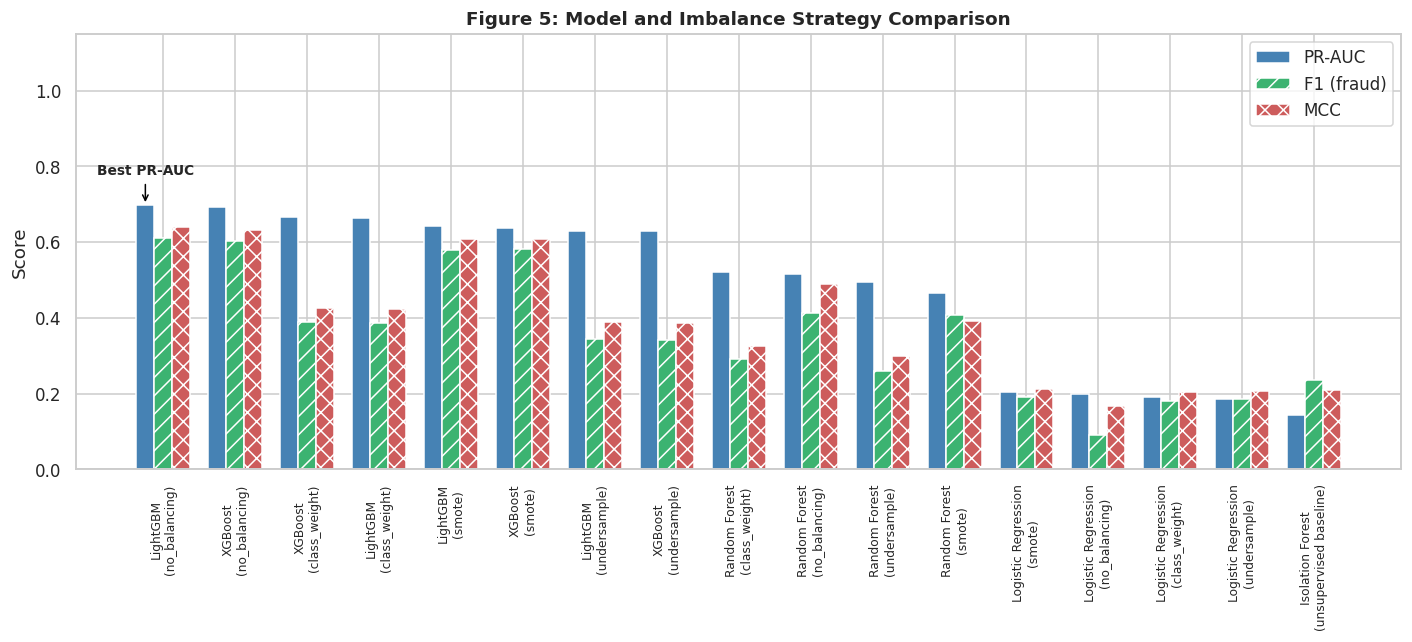


Best configuration: LightGBM + no_balancing
PR-AUC = 0.6975, F1 = 0.6110, MCC = 0.6395


In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

results_df["Combo"] = results_df["Model"] + "\n(" + results_df["Strategy"] + ")"
plot_df = results_df.sort_values("PR-AUC", ascending=False)

x = np.arange(len(plot_df))
width = 0.25

ax.bar(x - width, plot_df["PR-AUC"], width, label="PR-AUC", color="steelblue")
ax.bar(x,          plot_df["F1 (fraud)"], width, label="F1 (fraud)", color="mediumseagreen", hatch="//")
ax.bar(x + width, plot_df["MCC"], width, label="MCC", color="indianred", hatch="xx")

ax.annotate("Best PR-AUC", xy=(0 - width, plot_df["PR-AUC"].iloc[0]),
            xytext=(0 - width, plot_df["PR-AUC"].iloc[0] + 0.08),
            ha="center", fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="black"))

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Combo"], rotation=90, fontsize=8)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.15)
ax.set_title("Figure 5: Model and Imbalance Strategy Comparison", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("ieee_fig5_model_comparison.png", bbox_inches="tight")
plt.show()

best_row = results_df.iloc[0]
print(f"\nBest configuration: {best_row['Model']} + {best_row['Strategy']}")
print(f"PR-AUC = {best_row['PR-AUC']:.4f}, F1 = {best_row['F1 (fraud)']:.4f}, MCC = {best_row['MCC']:.4f}")

## 8. Best Model: Detailed Evaluation

### Reusing the model, not retraining a third time

In [ ]:
best_strategy = best_row["Strategy"]
best_model_name = best_row["Model"]
best_model = trained_models[(best_strategy, best_model_name)]

if best_model_name == "Isolation Forest":
    best_preds = np.where(best_model.predict(X_val) == -1, 1, 0)
    best_probs = -best_model.score_samples(X_val)
else:
    best_preds = best_model.predict(X_val)
    best_probs = best_model.predict_proba(X_val)[:, 1]

print(f"Winning configuration: {best_model_name} + {best_strategy}  (trained on the full training split)")
print(classification_report(y_val, best_preds, target_names=["Legitimate", "Fraud"]))

Winning configuration: LightGBM + no_balancing  (trained on the full training split)
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99    113975
       Fraud       0.91      0.46      0.61      4133

    accuracy                           0.98    118108
   macro avg       0.95      0.73      0.80    118108
weighted avg       0.98      0.98      0.98    118108



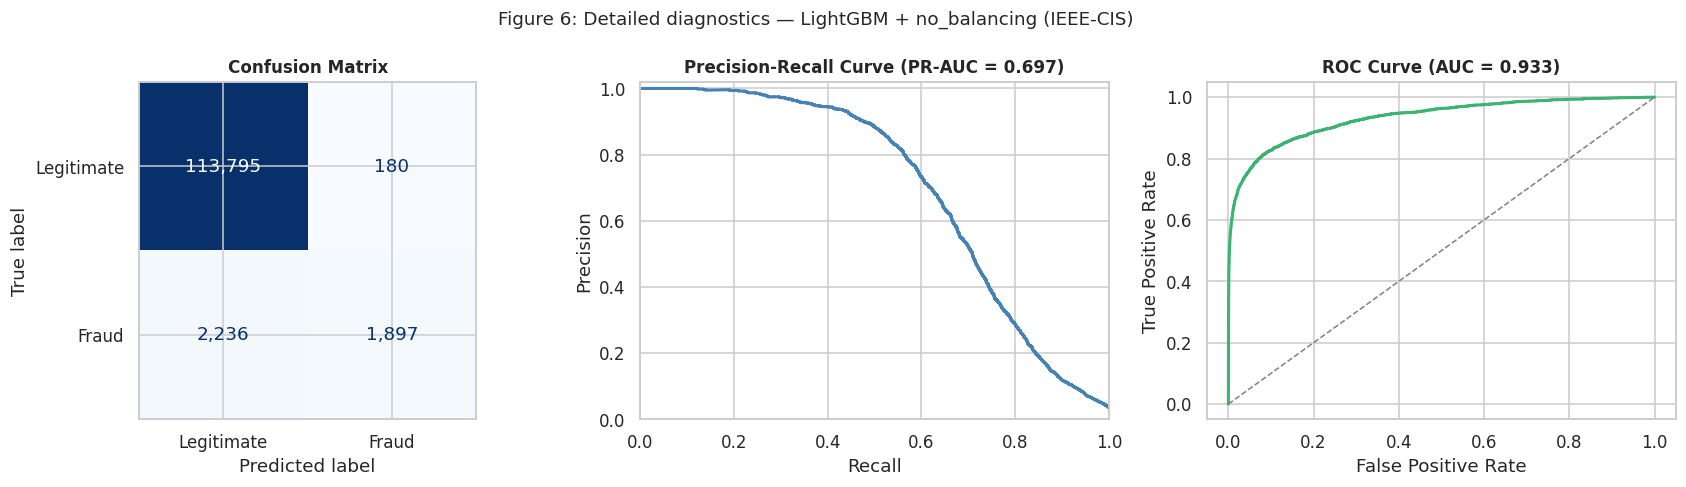

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm = confusion_matrix(y_val, best_preds)
ConfusionMatrixDisplay(cm, display_labels=["Legitimate", "Fraud"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format=",")
axes[0].set_title("Confusion Matrix", fontsize=11, fontweight="bold")

precision, recall, _ = precision_recall_curve(y_val, best_probs)
pr_auc = average_precision_score(y_val, best_probs)
axes[1].plot(recall, precision, color="steelblue", linewidth=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall Curve (PR-AUC = {pr_auc:.3f})", fontsize=11, fontweight="bold")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)

fpr, tpr, _ = roc_curve(y_val, best_probs)
roc_auc = roc_auc_score(y_val, best_probs)
axes[2].plot(fpr, tpr, color="mediumseagreen", linewidth=2)
axes[2].plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title(f"ROC Curve (AUC = {roc_auc:.3f})", fontsize=11, fontweight="bold")

fig.suptitle(f"Figure 6: Detailed diagnostics — {best_model_name} + {best_strategy} (IEEE-CIS)", fontsize=12)
plt.tight_layout()
plt.savefig("ieee_fig6_best_model_diagnostics.png", bbox_inches="tight")
plt.show()

In [ ]:
review_table = X_val.copy()
review_table["TransactionID"] = train.loc[X_val.index, "TransactionID"].values
review_table["fraud_probability"] = best_probs
review_table["predicted_label"] = best_preds
review_table["true_label"] = y_val.values

def classify_outcome(row):
    if row["true_label"] == 1 and row["predicted_label"] == 1:
        return "True Positive"
    elif row["true_label"] == 0 and row["predicted_label"] == 0:
        return "True Negative"
    elif row["true_label"] == 0 and row["predicted_label"] == 1:
        return "False Positive"
    else:
        return "False Negative"

review_table["outcome"] = review_table.apply(classify_outcome, axis=1)

display_cols = ["TransactionID", "TransactionAmt", "ProductCD", "card4", "card6",
                 "fraud_probability", "predicted_label", "true_label", "outcome"]

print(review_table["outcome"].value_counts())
review_table[display_cols].sort_values("fraud_probability", ascending=False).head(10)

outcome
True Negative     113795
False Negative      2236
True Positive       1897
False Positive       180
Name: count, dtype: int64


,TransactionID,TransactionAmt,ProductCD,card4,card6,fraud_probability,predicted_label,true_label,outcome
394611,3381611,2.133345,0.064032,0.321627,0.253152,0.999922,1,1,True Positive
24068,3011068,0.268997,0.064032,0.321627,0.746768,0.999819,1,1,True Positive
132009,3119009,0.683297,0.064032,0.321627,0.253152,0.999768,1,1,True Positive
34823,3021823,0.683297,0.055934,0.321627,0.253152,0.999735,1,1,True Positive
382443,3369443,0.683297,0.064032,0.653052,0.746768,0.999708,1,1,True Positive
191667,3178667,0.061848,0.055934,0.321627,0.746768,0.999701,1,1,True Positive
431591,3418591,-0.201987,0.116391,0.653052,0.746768,0.999601,1,1,True Positive
24025,3011025,0.268997,0.064032,0.321627,0.746768,0.999592,1,1,True Positive
179829,3166829,0.268997,0.064032,0.321627,0.253152,0.999497,1,1,True Positive
547449,3534449,0.061848,0.055934,0.321627,0.746768,0.999479,1,1,True Positive


**Looking specifically at the mistakes:**

In [ ]:
false_negatives = review_table[review_table["outcome"] == "False Negative"].sort_values(
    "fraud_probability", ascending=False
)
false_positives = review_table[review_table["outcome"] == "False Positive"].sort_values(
    "fraud_probability", ascending=False
)

print(f"{len(false_negatives)} missed fraud cases (False Negatives) on the validation set")
print(f"{len(false_positives)} wrongly flagged legitimate transactions (False Positives)")

print("\nExamples of missed fraud (highest probability first, still below threshold):")
display(false_negatives[display_cols].head(5))

print("\nExamples of wrongly flagged legitimate transactions:")
display(false_positives[display_cols].head(5))

2236 missed fraud cases (False Negatives) on the validation set
180 wrongly flagged legitimate transactions (False Positives)

Examples of missed fraud (highest probability first, still below threshold):


,TransactionID,TransactionAmt,ProductCD,card4,card6,fraud_probability,predicted_label,true_label,outcome
435615,3422615,-0.495414,0.116391,0.653052,0.253152,0.499710,0,1,False Negative
557928,3544928,-0.315165,0.743917,0.653052,0.746768,0.498288,0,1,False Negative
575833,3562833,-0.159703,0.116391,0.653052,0.746768,0.497355,0,1,False Negative
394375,3381375,1.205314,0.743917,0.653052,0.746768,0.496143,0,1,False Negative
464563,3451563,-0.074871,0.743917,0.321627,0.253152,0.492908,0,1,False Negative



Examples of wrongly flagged legitimate transactions:


,TransactionID,TransactionAmt,ProductCD,card4,card6,fraud_probability,predicted_label,true_label,outcome
582749,3569749,-0.029294,0.116391,0.653052,0.253152,0.975558,1,0,False Positive
117168,3104168,-0.498733,0.116391,0.653052,0.746768,0.971536,1,0,False Positive
410488,3397488,-0.378118,0.116391,0.653052,0.746768,0.970195,1,0,False Positive
143829,3130829,-0.508394,0.116391,0.321627,0.746768,0.946717,1,0,False Positive
233086,3220086,-0.145302,0.055934,0.321627,0.253152,0.943481,1,0,False Positive


## 9. Temporal Split Validation

### Why the random split from Section 4 might be too optimistic


In [ ]:
RANDOM_STATE = 42

# TransactionDT isn't a real date, but it's in order, so sorting by it works
train_sorted = train.sort_values("TransactionDT").reset_index(drop=True)
cutoff = int(len(train_sorted) * 0.8)

temporal_train_raw = train_sorted.iloc[:cutoff]
temporal_test_raw = train_sorted.iloc[cutoff:]

y_temporal_train = temporal_train_raw["isFraud"]
y_temporal_test = temporal_test_raw["isFraud"]
X_temporal_train = temporal_train_raw.drop(columns=["isFraud", "TransactionID"])
X_temporal_test = temporal_test_raw.drop(columns=["isFraud", "TransactionID"])

print(f"Temporal train: {len(X_temporal_train):,} rows, fraud rate {y_temporal_train.mean()*100:.3f}%")
print(f"Temporal test:  {len(X_temporal_test):,} rows, fraud rate {y_temporal_test.mean()*100:.3f}%")

Temporal train: 472,432 rows, fraud rate 3.514%
Temporal test:  118,108 rows, fraud rate 3.441%


In [ ]:
RANDOM_STATE = 42

cat_cols_temporal = X_temporal_train.select_dtypes(include=["object"]).columns.tolist()
freq_maps_temporal = {col: X_temporal_train[col].value_counts(normalize=True) for col in cat_cols_temporal}

apply_frequency_encoding(X_temporal_train, freq_maps_temporal)
apply_frequency_encoding(X_temporal_test, freq_maps_temporal)

temporal_medians = X_temporal_train.median(numeric_only=True)
for col in temporal_medians.index:
    if X_temporal_train[col].isna().any():
        X_temporal_train[col] = X_temporal_train[col].fillna(temporal_medians[col])
    if X_temporal_test[col].isna().any():
        X_temporal_test[col] = X_temporal_test[col].fillna(temporal_medians[col])

temporal_scaler = StandardScaler()
X_temporal_train[scale_cols] = temporal_scaler.fit_transform(X_temporal_train[scale_cols])
X_temporal_test[scale_cols] = temporal_scaler.transform(X_temporal_test[scale_cols])

### Retraining the winning configuration under the temporal split

In [ ]:
RANDOM_STATE = 42

if best_model_name == "Isolation Forest":
    # same as Section 7 - Isolation Forest doesn't need resampling or class weights
    contamination_temp = min(0.5, y_temporal_train.mean())
    temporal_model = IsolationForest(n_estimators=200, contamination=contamination_temp,
                                      random_state=RANDOM_STATE, n_jobs=-1)
    temporal_model.fit(X_temporal_train)
    temporal_preds = np.where(temporal_model.predict(X_temporal_test) == -1, 1, 0)
    temporal_score = -temporal_model.score_samples(X_temporal_test)
else:
    X_temp_res, y_temp_res = get_resampled_data(best_strategy, X_temporal_train, y_temporal_train)

    # same rule as Section 7 - only turn on class weighting for the class_weight condition
    apply_cw_temp = (best_strategy == "class_weight")
    original_scale_pos_weight_temp = (y_temporal_train == 0).sum() / (y_temporal_train == 1).sum()
    temporal_model = get_supervised_models(apply_cw_temp, original_scale_pos_weight_temp)[best_model_name]

    temporal_model.fit(X_temp_res, y_temp_res)
    temporal_preds = temporal_model.predict(X_temporal_test)
    temporal_score = temporal_model.predict_proba(X_temporal_test)[:, 1]

temporal_metrics = evaluate_predictions(y_temporal_test, temporal_preds, temporal_score)

print(f"Temporal-split performance for {best_model_name} + {best_strategy}:")
for k, v in temporal_metrics.items():
    print(f"  {k}: {v:.4f}")

Temporal-split performance for LightGBM + no_balancing:
  PR-AUC: 0.5105
  Precision: 0.7435
  Recall: 0.3565
  F1 (fraud): 0.4820
  MCC: 0.5039


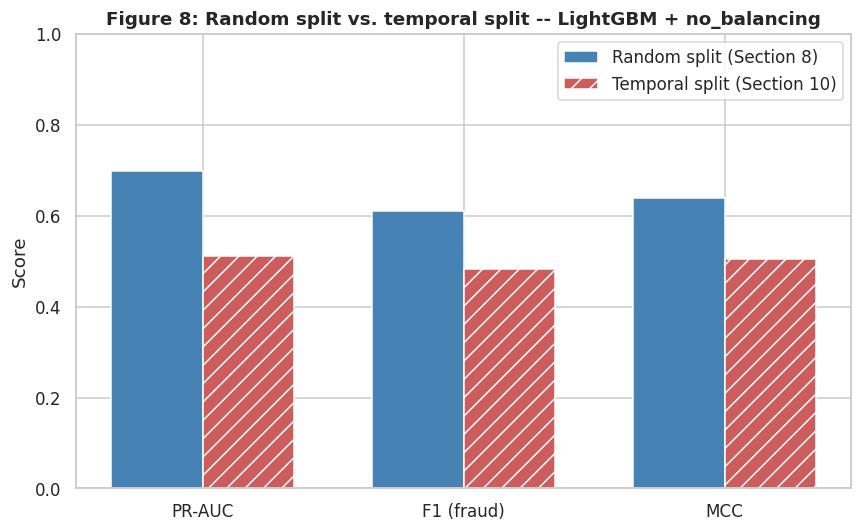

PR-AUC: random-split score is +0.1870 higher than temporal-split score
F1 (fraud): random-split score is +0.1290 higher than temporal-split score
MCC: random-split score is +0.1356 higher than temporal-split score


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

metric_names = ["PR-AUC", "F1 (fraud)", "MCC"]
random_vals = [best_row["PR-AUC"], best_row["F1 (fraud)"], best_row["MCC"]]
temporal_vals = [temporal_metrics["PR-AUC"], temporal_metrics["F1 (fraud)"], temporal_metrics["MCC"]]

x = np.arange(len(metric_names))
width = 0.35
ax.bar(x - width/2, random_vals, width, label="Random split (Section 8)", color="steelblue")
ax.bar(x + width/2, temporal_vals, width, label="Temporal split (Section 10)", color="indianred", hatch="//")

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title(f"Figure 8: Random split vs. temporal split -- {best_model_name} + {best_strategy}",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("ieee_fig8_temporal_vs_random.png", bbox_inches="tight")
plt.show()

gap = np.array(random_vals) - np.array(temporal_vals)
for name, g in zip(metric_names, gap):
    print(f"{name}: random-split score is {g:+.4f} {'higher' if g > 0 else 'lower'} than temporal-split score")

## 10. Threshold Tuning

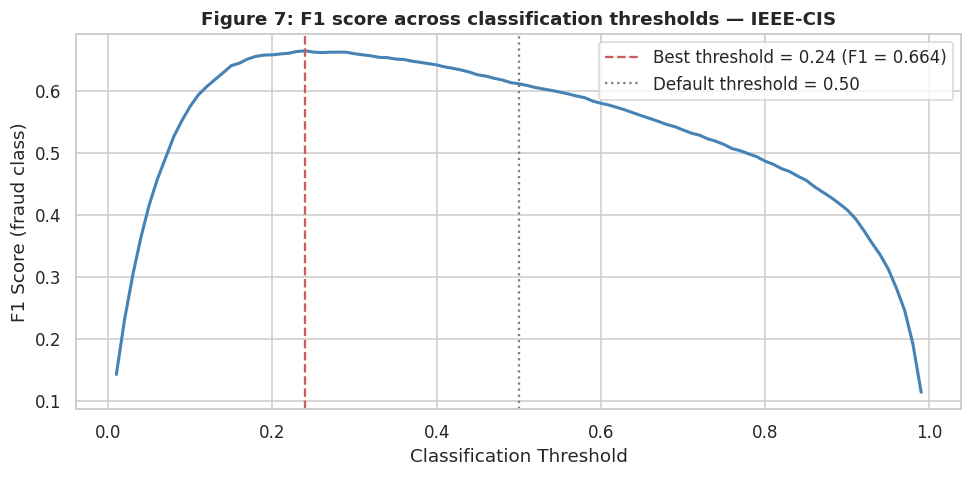

In [ ]:
thresholds = np.linspace(0.01, 0.99, 99)
f1_scores = [f1_score(y_val, (best_probs >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(thresholds, f1_scores, color="steelblue", linewidth=2)
ax.axvline(best_threshold, color="indianred", linestyle="--",
           label=f"Best threshold = {best_threshold:.2f} (F1 = {max(f1_scores):.3f})")
ax.axvline(0.5, color="grey", linestyle=":", label="Default threshold = 0.50")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("F1 Score (fraud class)")
ax.set_title("Figure 7: F1 score across classification thresholds — IEEE-CIS", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("ieee_fig7_threshold_tuning.png", bbox_inches="tight")
plt.show()

In [ ]:
# use the tuned threshold here, not the default 0.5 - so the false negatives
# shown below match the threshold the model actually uses
review_table["predicted_label"] = (review_table["fraud_probability"] >= best_threshold).astype(int)
review_table["outcome"] = review_table.apply(classify_outcome, axis=1)

false_negatives = review_table[review_table["outcome"] == "False Negative"].sort_values(
    "fraud_probability", ascending=False
)
false_positives = review_table[review_table["outcome"] == "False Positive"].sort_values(
    "fraud_probability", ascending=False
)

print(f"{len(false_negatives)} missed fraud cases (False Negatives) at the tuned threshold")
print(f"{len(false_positives)} wrongly flagged legitimate transactions (False Positives)")

1716 missed fraud cases (False Negatives) at the tuned threshold
730 wrongly flagged legitimate transactions (False Positives)


## 11. SHAP Explainability

In [ ]:
RANDOM_STATE = 42

shap_sample = X_val.sample(n=min(2000, len(X_val)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(shap_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

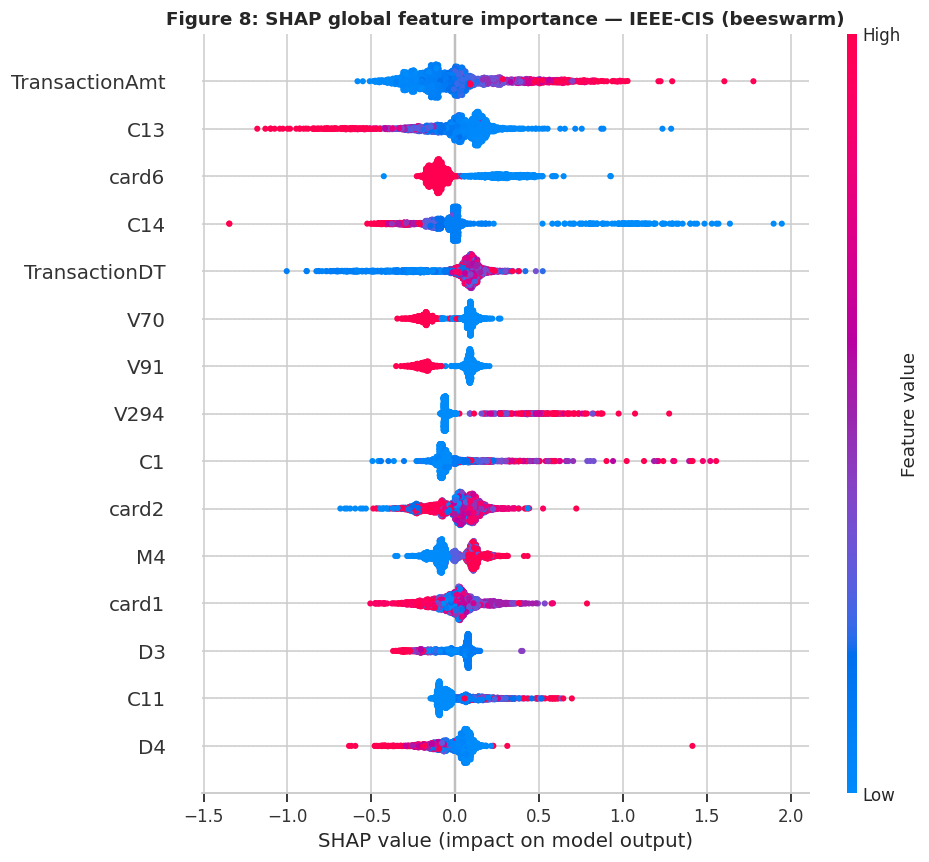

In [ ]:
fig = plt.figure(figsize=(9, 8))
shap.summary_plot(shap_values, shap_sample, show=False, plot_size=None, max_display=15)
plt.title("Figure 8: SHAP global feature importance — IEEE-CIS (beeswarm)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("ieee_fig8_shap_summary.png", bbox_inches="tight")
plt.show()

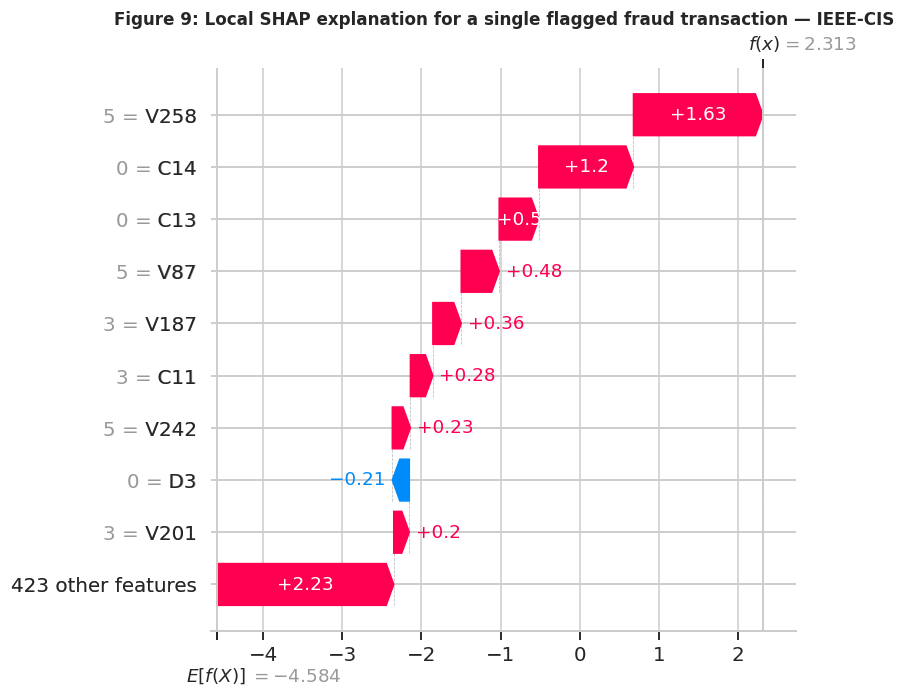

In [ ]:
y_val_reset = y_val.reset_index(drop=True)
shap_sample_reset = shap_sample.reset_index(drop=True)
fraud_positions = shap_sample.reset_index().index[
    y_val.loc[shap_sample.index].values == 1
]

if len(fraud_positions) > 0:
    example_position = fraud_positions[0]
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[example_position],
            base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                        else explainer.expected_value[1],
            data=shap_sample.iloc[example_position],
            feature_names=shap_sample.columns.tolist()
        ),
        show=False
    )
    plt.title("Figure 9: Local SHAP explanation for a single flagged fraud transaction — IEEE-CIS",
              fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig("ieee_fig9_shap_local.png", bbox_inches="tight")
    plt.show()
else:
    print("No fraud cases landed in the SHAP sample — re-run with a larger sample size.")

In [ ]:
def explain_transaction(row_features, top_n=5):
    row_df = row_features.to_frame().T
    sv = explainer.shap_values(row_df)
    if isinstance(sv, list):
        sv = sv[1]
    sv = sv[0]

    contributions = pd.DataFrame({
        "feature": row_df.columns,
        "value": row_df.iloc[0].values,
        "shap_value": sv
    })
    contributions["abs_shap"] = contributions["shap_value"].abs()
    return contributions.sort_values("abs_shap", ascending=False).head(top_n)

def explanation_to_text(contributions):
    lines = []
    for _, r in contributions.iterrows():
        direction = "pushed the score UP (more fraud-like)" if r["shap_value"] > 0 else \
                    "pushed the score DOWN (less fraud-like)"
        lines.append(f"    - {r['feature']} = {r['value']:.3f}  ->  {direction}  "
                      f"(contribution: {r['shap_value']:+.3f})")
    return "\n".join(lines)

In [ ]:
print("Why the model under-scored these genuinely fraudulent transactions:\n")

for idx in false_negatives.head(3).index:
    row = X_val.loc[idx]
    txn_id = review_table.loc[idx, "TransactionID"]
    prob = review_table.loc[idx, "fraud_probability"]
    print(f"TransactionID {txn_id}  (true label: fraud, model's score: {prob:.3f}, "
          f"threshold: {best_threshold:.3f})")
    print(explanation_to_text(explain_transaction(row)))
    print()

Why the model under-scored these genuinely fraudulent transactions:

TransactionID 3186709  (true label: fraud, model's score: 0.239, threshold: 0.240)
    - V258 = 3.000  ->  pushed the score UP (more fraud-like)  (contribution: +1.940)
    - card3 = 185.000  ->  pushed the score UP (more fraud-like)  (contribution: +0.534)
    - C1 = 2.000  ->  pushed the score DOWN (less fraud-like)  (contribution: -0.510)
    - D2 = 410.000  ->  pushed the score DOWN (less fraud-like)  (contribution: -0.337)
    - card1 = 9633.000  ->  pushed the score UP (more fraud-like)  (contribution: +0.282)

TransactionID 3505897  (true label: fraud, model's score: 0.239, threshold: 0.240)
    - C14 = 0.000  ->  pushed the score UP (more fraud-like)  (contribution: +1.288)
    - R_emaildomain = 0.415  ->  pushed the score UP (more fraud-like)  (contribution: +0.425)
    - card6 = 0.253  ->  pushed the score UP (more fraud-like)  (contribution: +0.383)
    - card3 = 185.000  ->  pushed the score UP (more fraud

## 12. Cost-Sensitive Business Evaluation

In [ ]:
RANDOM_STATE = 42
AVG_INVESTIGATION_COST = 75.0  # GBP, Home Office (2026) finance-industry response unit cost

avg_fraud_amount = train.loc[train["isFraud"] == 1, "TransactionAmt"].mean()
print(f"Average fraudulent transaction amount in this dataset: £{avg_fraud_amount:.2f}")

def business_cost(y_true, y_pred, avg_fraud_amount, investigation_cost):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost_fn = fn * avg_fraud_amount
    cost_fp = fp * investigation_cost
    cost_tp = tp * investigation_cost
    saving_tp = tp * avg_fraud_amount
    net_cost = cost_fn + cost_fp + cost_tp - saving_tp
    return net_cost, {"TN": tn, "FP": fp, "FN": fn, "TP": tp}

Average fraudulent transaction amount in this dataset: £149.24


In [ ]:
cost_results = []

for (strategy, model_name), model in trained_models.items():
    if model_name == "Isolation Forest":
        y_pred = np.where(model.predict(X_val) == -1, 1, 0)
    else:
        y_pred = model.predict(X_val)

    net_cost, breakdown = business_cost(y_val, y_pred, avg_fraud_amount, AVG_INVESTIGATION_COST)
    cost_results.append({"Model": model_name, "Strategy": strategy, "Net Cost (GBP)": net_cost,
                          **breakdown})

cost_df = pd.DataFrame(cost_results).sort_values("Net Cost (GBP)").reset_index(drop=True)
cost_df[["Model", "Strategy", "Net Cost (GBP)", "FN", "FP", "TP"]]

,Model,Strategy,Net Cost (GBP),FN,FP,TP
0,LightGBM,no_balancing,2.063690e+05,2236,180,1897
1,XGBoost,no_balancing,2.156055e+05,2278,178,1855
2,XGBoost,smote,2.348619e+05,2340,250,1793
3,LightGBM,smote,2.362657e+05,2354,227,1779
4,Random Forest,no_balancing,3.788516e+05,3042,78,1091
5,Random Forest,smote,4.559686e+05,1988,4247,2145
6,Logistic Regression,no_balancing,5.809883e+05,3928,133,205
7,XGBoost,class_weight,6.045415e+05,748,9923,3385
8,LightGBM,class_weight,6.105264e+05,758,9973,3375
9,Isolation Forest,unsupervised baseline,6.344339e+05,3153,3155,980


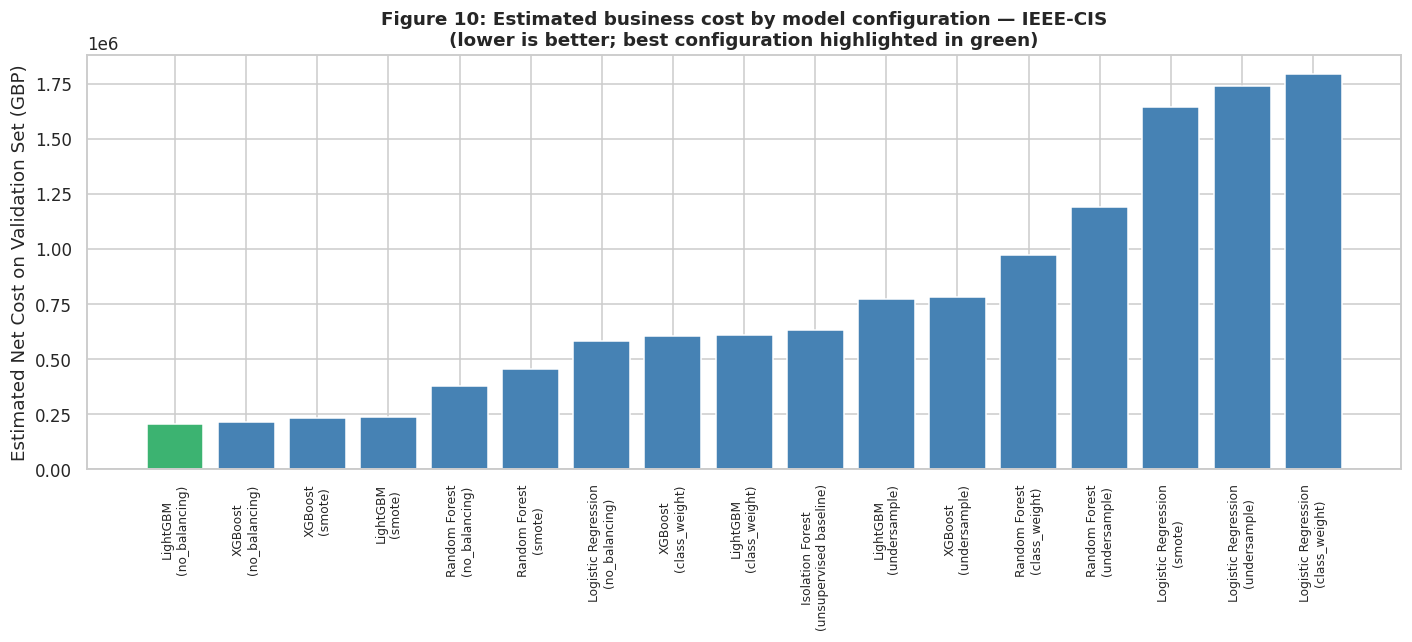

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

cost_plot_df = cost_df.sort_values("Net Cost (GBP)")
cost_plot_df["Combo"] = cost_plot_df["Model"] + "\n(" + cost_plot_df["Strategy"] + ")"
colors = ["mediumseagreen" if c == cost_plot_df["Net Cost (GBP)"].min() else "steelblue"
          for c in cost_plot_df["Net Cost (GBP)"]]

ax.bar(cost_plot_df["Combo"], cost_plot_df["Net Cost (GBP)"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Estimated Net Cost on Validation Set (GBP)")
ax.set_title("Figure 10: Estimated business cost by model configuration — IEEE-CIS\n"
             "(lower is better; best configuration highlighted in green)",
             fontsize=12, fontweight="bold")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig("ieee_fig10_cost_comparison.png", bbox_inches="tight")
plt.show()

## 13. Scoring the Test Set and Building a Fraud Alert List

In [ ]:
test_probs = best_model.predict_proba(X_test_unlabelled)[:, 1]

# Every transaction gets scored, but nothing is written out for all of them yet
scored = test[["TransactionID", "TransactionAmt", "ProductCD", "card4", "card6"]].copy()
scored["fraud_probability"] = test_probs

# reuse best_threshold from Section 11 instead of the default 0.5
alert_list = scored[scored["fraud_probability"] >= best_threshold].sort_values(
    "fraud_probability", ascending=False
).reset_index(drop=True)

print(f"{len(scored):,} transactions scored in total")
print(f"{len(alert_list):,} transactions flagged for review "
      f"({len(alert_list) / len(scored) * 100:.2f}% of the test set) "
      f"at threshold {best_threshold:.2f}")
alert_list.head(20)

506,691 transactions scored in total
16,232 transactions flagged for review (3.20% of the test set) at threshold 0.24


,TransactionID,TransactionAmt,ProductCD,card4,card6,fraud_probability
0,3756730,150.000000,R,discover,credit,0.999838
1,4138550,375.000000,R,mastercard,debit,0.999778
2,3756729,150.000000,R,discover,credit,0.999759
3,3779432,250.000000,R,discover,credit,0.999720
4,3814787,175.000000,R,visa,credit,0.999715
5,3919942,150.000000,H,visa,credit,0.999665
6,3739395,250.000000,R,american express,credit,0.999610
7,3793491,225.000000,R,american express,credit,0.999587
8,3919936,150.000000,H,visa,credit,0.999574
9,3731794,70.702003,C,visa,credit,0.999562


In [ ]:
RANDOM_STATE = 42
TARGET_PRECISION = 0.80

precision_arr, recall_arr, thresh_arr = precision_recall_curve(y_val, best_probs)

# precision_arr has one extra value vs thresh_arr, so align with [:-1]
high_precision_thresholds = thresh_arr[precision_arr[:-1] >= TARGET_PRECISION]

if len(high_precision_thresholds) > 0:
    decline_threshold = high_precision_thresholds.min()
else:
    decline_threshold = 0.99
    print(f"No threshold on the validation set reached {TARGET_PRECISION:.0%} precision -- "
          f"falling back to a conservative 0.99 cutoff for the High tier.")

# make sure decline_threshold isn't below best_threshold (tiers would overlap otherwise)
decline_threshold = max(decline_threshold, best_threshold + 0.01)

print(f"Low / Medium boundary (review threshold, from Section 11): {best_threshold:.3f}")
print(f"Medium / High boundary (decline threshold, {TARGET_PRECISION:.0%} precision): {decline_threshold:.3f}")

Low / Medium boundary (review threshold, from Section 11): 0.240
Medium / High boundary (decline threshold, 80% precision): 0.273


### Applying the tiers to the scored test set

In [ ]:
def assign_tier(prob):
    if prob >= decline_threshold:
        return "High", "Decline / block"
    elif prob >= best_threshold:
        return "Medium", "Manual review / step-up authentication"
    else:
        return "Low", "Approve automatically"

tier_action = scored["fraud_probability"].apply(assign_tier)
scored["risk_tier"] = tier_action.apply(lambda x: x[0])
scored["action"] = tier_action.apply(lambda x: x[1])

tier_summary = scored.groupby("risk_tier").agg(
    transaction_count=("TransactionID", "count"),
    total_value=("TransactionAmt", "sum"),
    avg_probability=("fraud_probability", "mean")
).reindex(["Low", "Medium", "High"])

tier_summary["pct_of_transactions"] = (tier_summary["transaction_count"] / len(scored) * 100).round(2)
tier_summary

,transaction_count,total_value,avg_probability,pct_of_transactions
risk_tier,,,,
Low,490459,6.600672e+07,0.018899,96.80
Medium,1395,2.455954e+05,0.255692,0.28
High,14837,2.011914e+06,0.689323,2.93


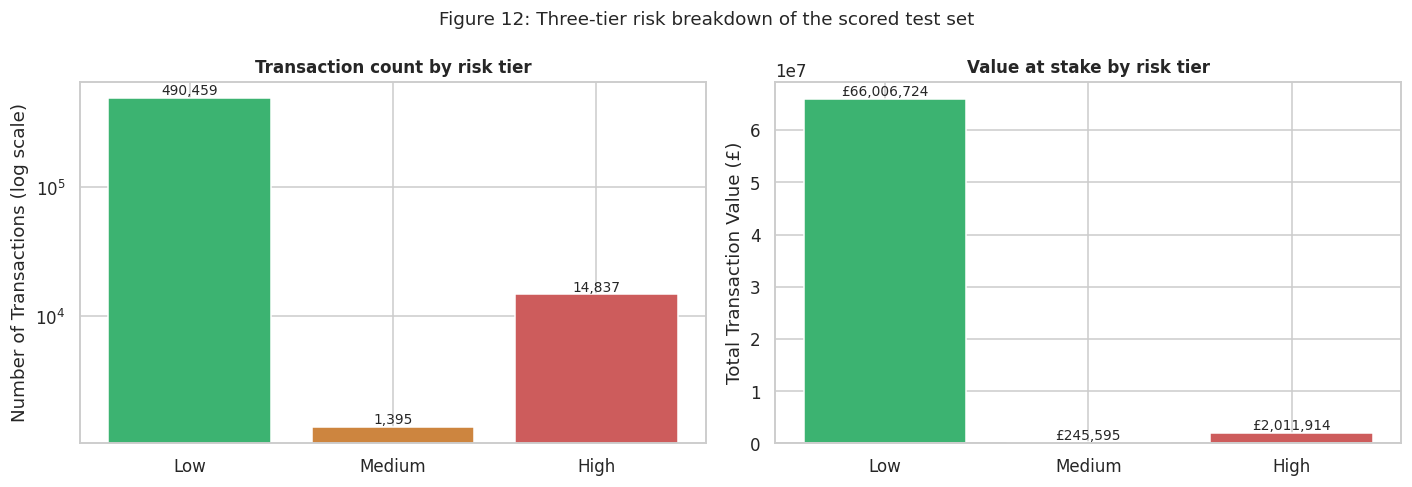

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = {"Low": "mediumseagreen", "Medium": "peru", "High": "indianred"}
tier_colors = [colors[t] for t in tier_summary.index]

axes[0].bar(tier_summary.index, tier_summary["transaction_count"], color=tier_colors)
axes[0].set_yscale("log")
axes[0].set_ylabel("Number of Transactions (log scale)")
axes[0].set_title("Transaction count by risk tier", fontsize=11, fontweight="bold")
for i, count in enumerate(tier_summary["transaction_count"]):
    axes[0].annotate(f"{count:,}", (i, count), ha="center", va="bottom", fontsize=9)

axes[1].bar(tier_summary.index, tier_summary["total_value"], color=tier_colors)
axes[1].set_ylabel("Total Transaction Value (£)")
axes[1].set_title("Value at stake by risk tier", fontsize=11, fontweight="bold")
for i, val in enumerate(tier_summary["total_value"]):
    axes[1].annotate(f"£{val:,.0f}", (i, val), ha="center", va="bottom", fontsize=9)

fig.suptitle("Figure 12: Three-tier risk breakdown of the scored test set", fontsize=12)
plt.tight_layout()
plt.savefig("ieee_fig12_risk_tiers.png", bbox_inches="tight")
plt.show()

### Saving the outputs

In [ ]:
review_and_decline = scored[scored["risk_tier"].isin(["Medium", "High"])].sort_values(
    "fraud_probability", ascending=False
)
review_and_decline.to_csv("ieee_cis_risk_tiers.csv", index=False)
print(f"Risk-tier list written: {len(review_and_decline):,} rows "
      f"({(review_and_decline['risk_tier']=='High').sum():,} High, "
      f"{(review_and_decline['risk_tier']=='Medium').sum():,} Medium) -> ieee_cis_risk_tiers.csv")

Risk-tier list written: 16,232 rows (14,837 High, 1,395 Medium) -> ieee_cis_risk_tiers.csv
